In [ ]:
dist_sft_wisub_ch1_v1_100_150k
onlyRefAns_webinstructsub_chunk1_v1_50_150k
sft_wi_ch1_100k
wi_ch1_100k/64gbs_gradAcc4_1epochs_1e6

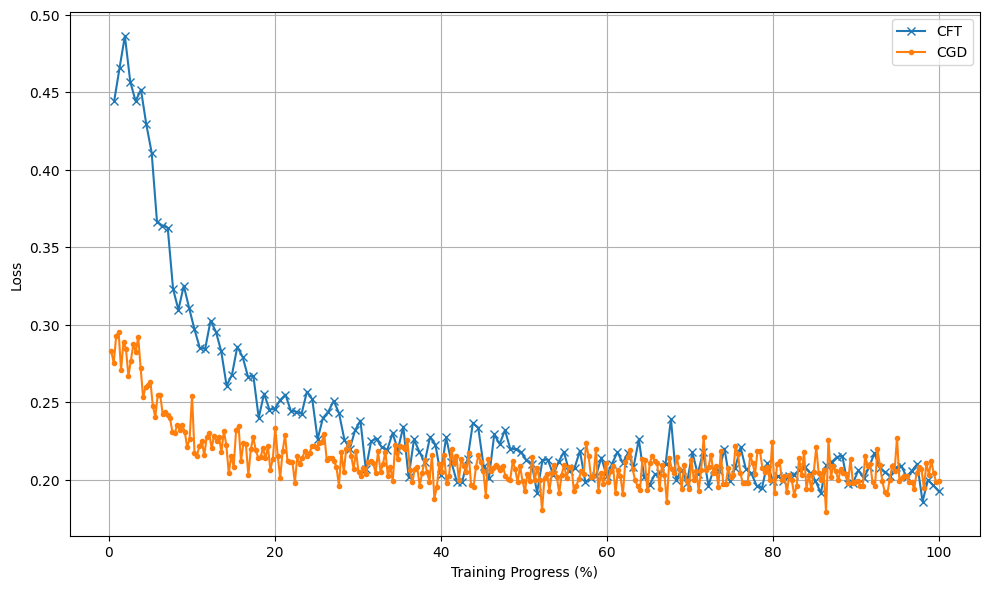

In [3]:
import json
import matplotlib.pyplot as plt
import numpy as np

def load_and_normalize(file_path):
    steps = []
    losses = []
    with open(file_path, 'r') as f:
        for line in f:
            record = json.loads(line)
            if 'current_steps' in record and 'loss' in record:
                steps.append(record['current_steps'])
                losses.append(record['loss'])
    if not steps:
        return [], []
    max_step = max(steps)
    normalized_steps = [step / max_step * 100 for step in steps]
    return normalized_steps, losses

# Load and normalize data from two runs
file1 = 'wi_ch1_100k/64gbs_gradAcc4_1epochs_1e6/trainer_log.jsonl'
file2 = 'sft_wi_ch1_100k/64gbs_gradAcc4_1epochs_1e6/trainer_log.jsonl'
file3 = 'WebInstructCFT50K/64gbs_gradAcc4_1epochs/trainer_log.jsonl'
# file4 = 'onlyRefAns_webinstructsub_chunk1_v1_50_150k/64gbs_gradAcc4_1epochs_1e6/trainer_log.jsonl'
file4 = 'wi_ch1_v1_50_150k_improved_resp_woutcrit/64gbs_gradAcc4_1epochs_1e6/trainer_log.jsonl'
file5 = 'dist_sft_wisub_ch1_v1_100_150k/64gbs_gradAcc4_1epochs_1e6/trainer_log.jsonl'

steps1, losses1 = load_and_normalize(main_dir+file1)
steps2, losses2 = load_and_normalize(main_dir+file2)
steps3, losses3 = load_and_normalize(main_dir_cft+file3)
steps4, losses4 = load_and_normalize(main_dir+file4)
steps5, losses5 = load_and_normalize(main_dir+file5)

plt.figure(figsize=(10, 6))
# plt.plot(steps2, losses2, label='SFT', marker='x')
# plt.plot(steps5, losses5, label='Distilled SFT', marker='x')
plt.plot(steps3, losses3, label='CFT', marker='x')
# plt.plot(steps4, losses4, label='Distilled SFT WI 100K | critique ', marker='x')
plt.plot(steps1, losses1, label='CGD', marker='.')
# plt.plot(steps4, losses4, label='CGD without critique ', marker='x')
plt.xlabel('Training Progress (%)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



/opt/conda/lib/python3.12/site-packages/seaborn/relational.py:500: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax = plt.gca()


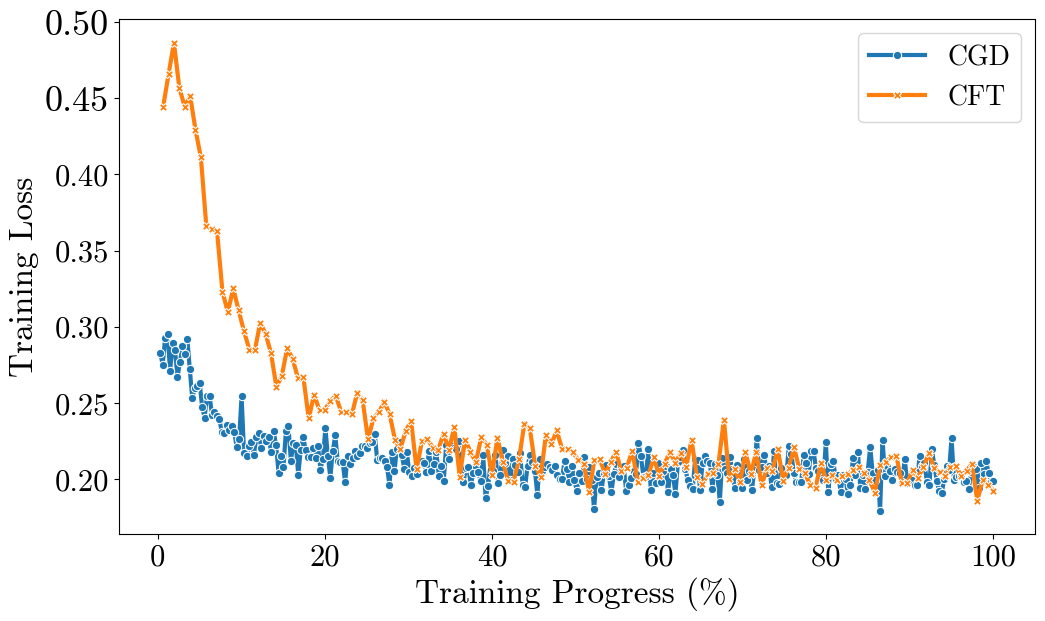

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["cmr10"],  # Computer Modern Roman
    "mathtext.fontset": "cm",  # Computer Modern for math
    "axes.labelsize": 24,
    "font.size": 20,
    "legend.fontsize": 22,
    "xtick.labelsize": 26,
    "ytick.labelsize": 26,
})



def load_and_normalize(file_path):
    steps = []
    losses = []
    with open(file_path, 'r') as f:
        for line in f:
            record = json.loads(line)
            if 'current_steps' in record and 'loss' in record:
                steps.append(record['current_steps'])
                losses.append(record['loss'])
    if not steps:
        return [], []
    max_step = max(steps)
    normalized_steps = [step / max_step * 100 for step in steps]
    return normalized_steps, losses

# Load and normalize data from two runs
file1 = 'wi_ch1_100k/64gbs_gradAcc4_1epochs_1e6/trainer_log.jsonl'
file3 = 'WebInstructCFT50K/64gbs_gradAcc4_1epochs/trainer_log.jsonl'

steps_cgd, losses1 = load_and_normalize(main_dir+file1)
steps_cft, losses3 = load_and_normalize(main_dir_cft+file3)

# # Generate percentage steps for normalized x-axis
# steps_cgd = np.linspace(0, 100, len(losses1))
# steps_cft = np.linspace(0, 100, len(losses3))

# Plot
plt.figure(figsize=(10, 6))
# sns.set(style="white", font_scale=1.2)

sns.lineplot(x=steps_cgd, y=losses1, label="CGD", marker="o", linewidth=3)
sns.lineplot(x=steps_cft, y=losses3, label="CFT", marker="X", linewidth=3)

plt.xlabel('Training Progress (%)', fontsize=24)
plt.ylabel('Training Loss', fontsize=24)
# plt.title('Loss Curves for CGD and CFT Methods')
plt.legend(fontsize=20)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.tight_layout(pad=0)
plt.savefig("../res/loss_curve.pdf", bbox_inches="tight")
plt.show()

